In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# S50 엑셀 파일 불러오기
# 파일명이 정확한지 확인 필요
import os
files = os.listdir(r'C:\Users\namy1')
excel_files = [f for f in files if f.endswith('.xlsx') or f.endswith('.xls')]
print(excel_files)

['hs50-long-run.xlsx']


In [3]:
# 엑셀 파일 불러오기 - 시트 확인
xl = pd.ExcelFile(r'C:\Users\namy1\hs50-long-run.xlsx')
print(xl.sheet_names)

['Data', 'Table Description', 'Series Definitions']


In [4]:
# Data 시트 불러오기
df = pd.read_excel(r'C:\Users\namy1\hs50-long-run.xlsx', sheet_name='Data', header=None)
print(df.shape)
print(df.head(10))

(217, 6)
                     0                               1  \
0                  NaN                     Total loans   
1                  NaN  Non-performing loans ratio (%)   
2                Notes                             NaN   
3                 Unit                               %   
4            Series Id                  BSAQS.MAR2A4.P   
5  2008-12-31 00:00:00                             0.9   
6  2009-01-31 00:00:00                               1   
7  2009-02-28 00:00:00                             1.1   
8  2009-03-31 00:00:00                             1.2   
9  2009-04-30 00:00:00                             1.3   

                                2                               3  \
0                   Housing loans         Personal consumer loans   
1  Non-performing loans ratio (%)  Non-performing loans ratio (%)   
2                             NaN                             NaN   
3                               %                               %   
4      

In [5]:
# 데이터 정제
df = pd.read_excel(r'C:\Users\namy1\hs50-long-run.xlsx', sheet_name='Data', header=None, skiprows=5)

# 컬럼명 지정
df.columns = ['Date', 'Total_NPL', 'Housing_NPL', 'Personal_NPL', 'Business_NPL', 'Agriculture_NPL']

# 날짜 변환
df['Date'] = pd.to_datetime(df['Date'])

# 2020년 이후 필터링
df = df[df['Date'] >= '2020-01-01'].reset_index(drop=True)

# 숫자 변환
for col in ['Total_NPL', 'Housing_NPL', 'Personal_NPL', 'Business_NPL']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.shape)
print(df.head())


(79, 6)
        Date  Total_NPL  Housing_NPL  Personal_NPL  Business_NPL  \
0 2020-01-31        0.6          0.3           1.2           0.6   
1 2020-02-29        0.6          0.2           1.2           0.6   
2 2020-03-31        0.6          0.3           1.3           0.6   
3 2020-04-30        0.7          0.3           1.6           0.7   
4 2020-05-31        0.7          0.3           1.7           0.8   

   Agriculture_NPL  
0              2.1  
1              2.1  
2              2.1  
3              2.1  
4              2.1  


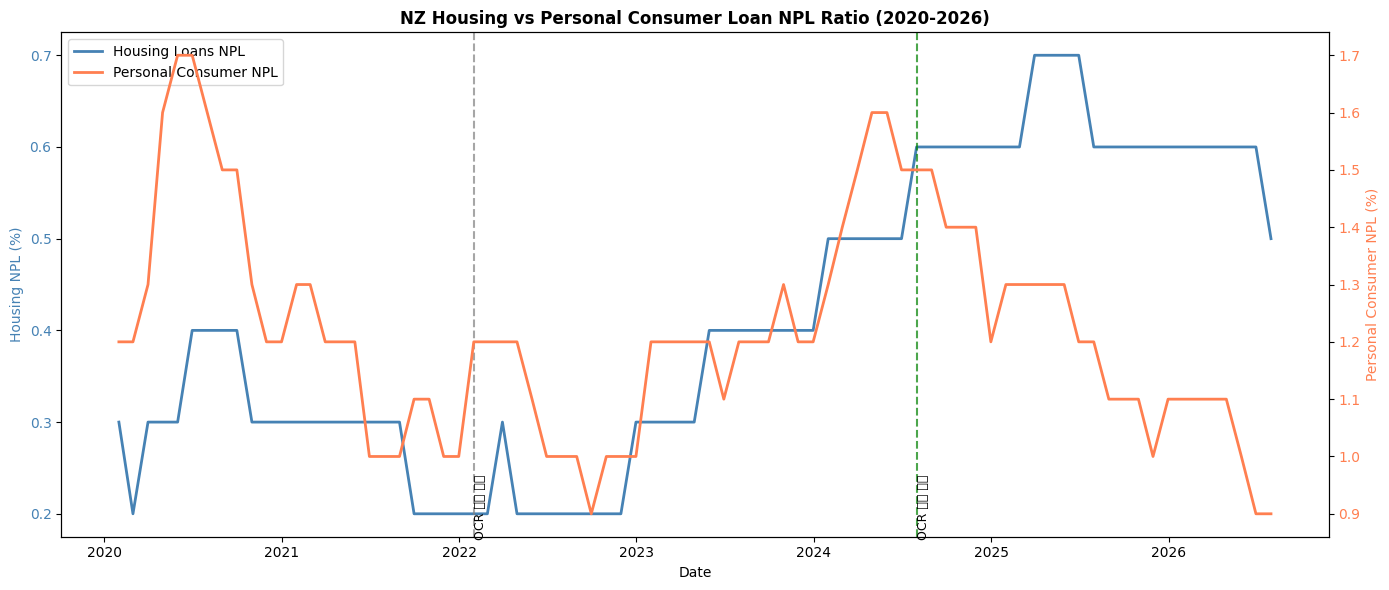

그래프 저장 완료!


In [6]:
# 시각화 - Housing NPL vs Personal NPL 트렌드
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df['Date'], df['Housing_NPL'], color='steelblue', linewidth=2, label='Housing Loans NPL')
ax1.set_xlabel('Date')
ax1.set_ylabel('Housing NPL (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Personal_NPL'], color='coral', linewidth=2, label='Personal Consumer NPL')
ax2.set_ylabel('Personal Consumer NPL (%)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# 주요 이벤트 표시
ax1.axvline(pd.Timestamp('2022-02-01'), color='gray', linestyle='--', alpha=0.7)
ax1.text(pd.Timestamp('2022-02-01'), ax1.get_ylim()[0], 'OCR 인상 시작', fontsize=9, rotation=90)
ax1.axvline(pd.Timestamp('2024-08-01'), color='green', linestyle='--', alpha=0.7)
ax1.text(pd.Timestamp('2024-08-01'), ax1.get_ylim()[0], 'OCR 인하 시작', fontsize=9, rotation=90)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('NZ Housing vs Personal Consumer Loan NPL Ratio (2020-2026)', fontweight='bold')
plt.tight_layout()
plt.savefig('npl_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 저장 완료!")

In [7]:
# 상관관계 분석 - 선행지표 검증
# Personal NPL이 Housing NPL보다 몇 달 앞서는지 확인

results = []
for lag in range(0, 13):  # 0~12개월 시차
    shifted = df['Personal_NPL'].shift(lag)
    corr, pvalue = stats.pearsonr(
        shifted.dropna(), 
        df['Housing_NPL'].iloc[lag:]
    )
    results.append({'Lag(months)': lag, 'Correlation': round(corr, 4), 'P-value': round(pvalue, 4)})

df_lag = pd.DataFrame(results)
print(df_lag)
print(f"\n최고 상관관계: {df_lag.loc[df_lag['Correlation'].idxmax()]}")

    Lag(months)  Correlation  P-value
0             0       0.2269   0.0444
1             1       0.2806   0.0128
2             2       0.3293   0.0034
3             3       0.3354   0.0031
4             4       0.3308   0.0037
5             5       0.3169   0.0059
6             6       0.2988   0.0102
7             7       0.2896   0.0136
8             8       0.2896   0.0143
9             9       0.3048   0.0103
10           10       0.3224   0.0069
11           11       0.3214   0.0075
12           12       0.2964   0.0149

최고 상관관계: Lag(months)    3.0000
Correlation    0.3354
P-value        0.0031
Name: 3, dtype: float64


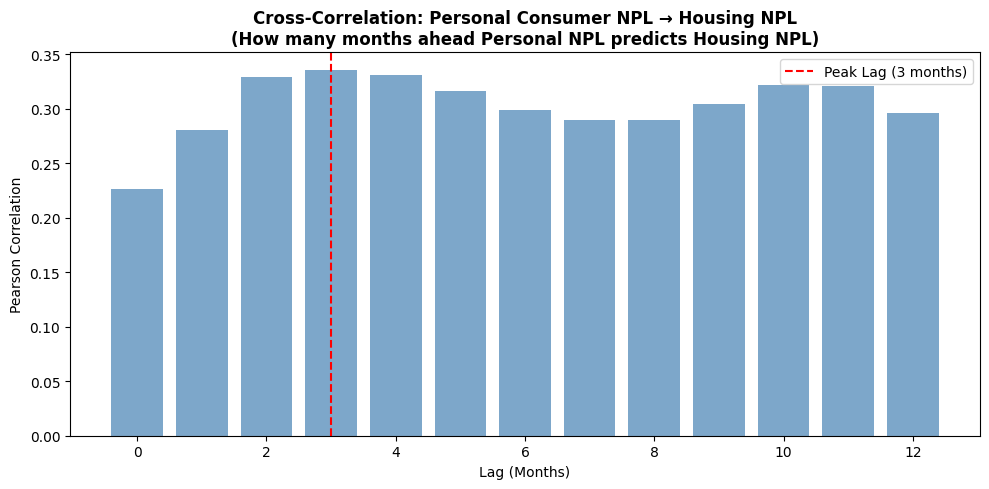

저장 완료!


In [8]:
# 시차 상관관계 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_lag['Lag(months)'], df_lag['Correlation'], color='steelblue', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Peak Lag (3 months)')
ax.set_xlabel('Lag (Months)')
ax.set_ylabel('Pearson Correlation')
ax.set_title('Cross-Correlation: Personal Consumer NPL → Housing NPL\n(How many months ahead Personal NPL predicts Housing NPL)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료!")

In [9]:
import os
files = os.listdir(r'C:\Users\namy1')
excel_files = [f for f in files if f.endswith('.xlsx') or f.endswith('.xls')]
print(excel_files)

['hb2-monthly-close.xlsx', 'hs50-long-run.xlsx']


In [10]:
# B2 금리 데이터 시트 확인
xl_b2 = pd.ExcelFile(r'C:\Users\namy1\hb2-monthly-close.xlsx')
print(xl_b2.sheet_names)

['Data', 'Table Description', 'Series Definitions']


In [11]:
# B2 데이터 확인
df_b2_raw = pd.read_excel(r'C:\Users\namy1\hb2-monthly-close.xlsx', sheet_name='Data', header=None)
print(df_b2_raw.shape)
print(df_b2_raw.head(8))

(109, 26)
                    0                         1                       2   \
0                  NaN                 Cash rate               Cash rate   
1                  NaN  Official Cash Rate (OCR)  Overnight Deposit Rate   
2                Notes                       NaN                     NaN   
3                 Unit                       %pa                     %pa   
4            Series Id             INM.MP1.N.nae           INM.MD1.N.nae   
5  2018-01-31 00:00:00                      1.75                    1.75   
6  2018-02-28 00:00:00                      1.75                    1.75   
7  2018-03-31 00:00:00                      1.75                    1.75   

                                           3                              4   \
0                                   Cash rate                      Cash rate   
1  Overnight Reverse Repurchase Facility Rate  Overnight interbank cash rate   
2                                         NaN                    

In [12]:
# OCR 데이터 추출
df_b2 = pd.read_excel(r'C:\Users\namy1\hb2-monthly-close.xlsx', sheet_name='Data', header=None, skiprows=5)
df_b2.columns = ['Date'] + [f'col_{i}' for i in range(1, 26)]

# Date랑 OCR만 추출
df_ocr = df_b2[['Date', 'col_1']].copy()
df_ocr.columns = ['Date', 'OCR']
df_ocr['Date'] = pd.to_datetime(df_ocr['Date'])
df_ocr['OCR'] = pd.to_numeric(df_ocr['OCR'], errors='coerce')

# 2020년 이후 필터링
df_ocr = df_ocr[df_ocr['Date'] >= '2020-01-01'].reset_index(drop=True)

print(df_ocr.shape)
print(df_ocr.head())

(80, 2)
        Date   OCR
0 2020-01-31  1.00
1 2020-02-29  1.00
2 2020-03-31  0.25
3 2020-04-30  0.25
4 2020-05-31  0.25


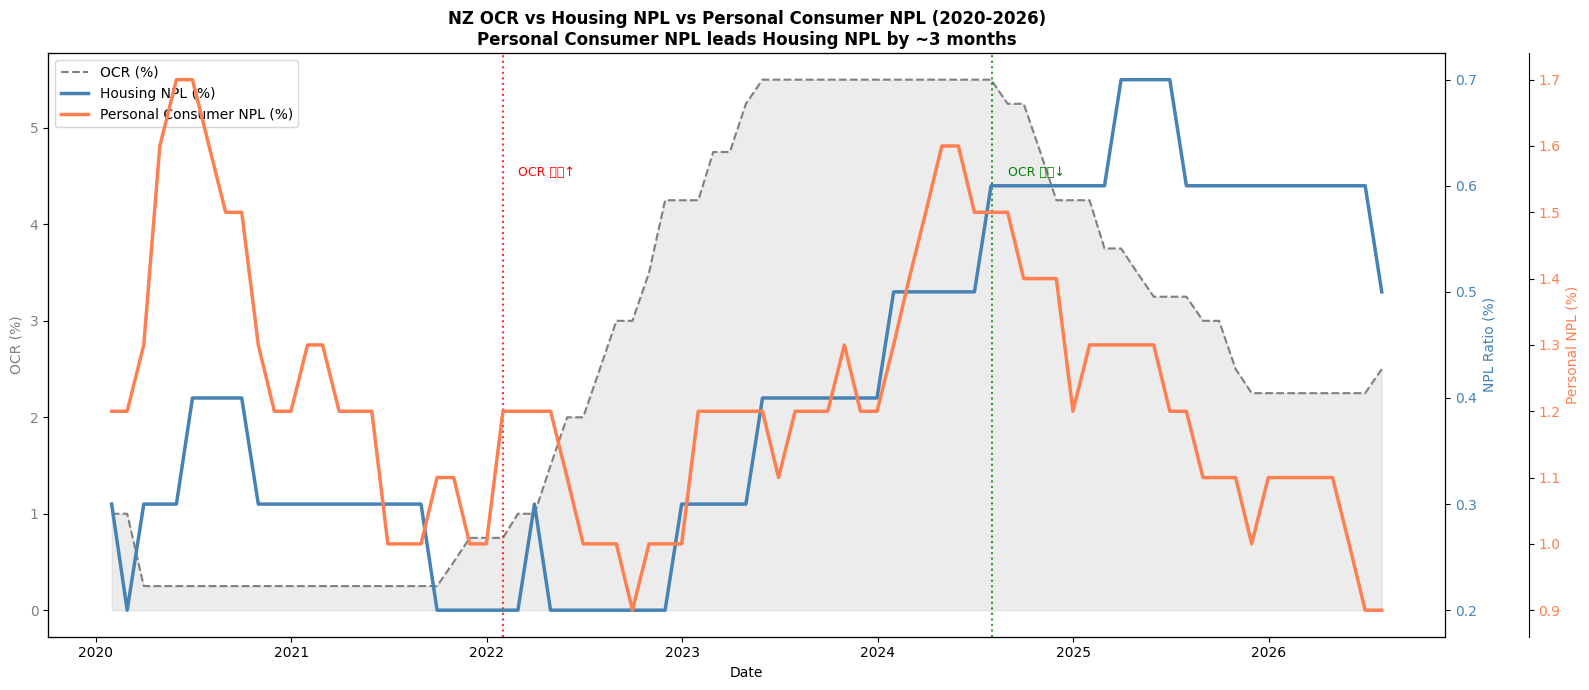

저장 완료!


In [13]:
# 세 데이터 합치기
df_merged = pd.merge(df, df_ocr, on='Date', how='inner')

# 3개 축 그래프
fig, ax1 = plt.subplots(figsize=(16, 7))

# OCR 금리
ax1.fill_between(df_merged['Date'], df_merged['OCR'], alpha=0.15, color='gray')
ax1.plot(df_merged['Date'], df_merged['OCR'], color='gray', linewidth=1.5, label='OCR (%)', linestyle='--')
ax1.set_xlabel('Date')
ax1.set_ylabel('OCR (%)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Housing NPL
ax2 = ax1.twinx()
ax2.plot(df_merged['Date'], df_merged['Housing_NPL'], color='steelblue', linewidth=2.5, label='Housing NPL (%)')
ax2.set_ylabel('NPL Ratio (%)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Personal Consumer NPL
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df_merged['Date'], df_merged['Personal_NPL'], color='coral', linewidth=2.5, label='Personal Consumer NPL (%)')
ax3.set_ylabel('Personal NPL (%)', color='coral')
ax3.tick_params(axis='y', labelcolor='coral')

# 주요 이벤트
ax1.axvline(pd.Timestamp('2022-02-01'), color='red', linestyle=':', alpha=0.8)
ax1.text(pd.Timestamp('2022-03-01'), 4.5, 'OCR 인상↑', fontsize=9, color='red')
ax1.axvline(pd.Timestamp('2024-08-01'), color='green', linestyle=':', alpha=0.8)
ax1.text(pd.Timestamp('2024-09-01'), 4.5, 'OCR 인하↓', fontsize=9, color='green')

# 범례
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.title('NZ OCR vs Housing NPL vs Personal Consumer NPL (2020-2026)\nPersonal Consumer NPL leads Housing NPL by ~3 months', fontweight='bold')
plt.tight_layout()
plt.savefig('ocr_npl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료!")